# LAT 1 transition: v1.0


In [1]:
from deep_cartograph.tools import traj_projection, compute_features
from deep_cartograph.deep_carto import deep_cartograph 
from deep_cartograph.modules.common import check_data
import importlib.resources as resources
from deep_cartograph import data

from IPython.display import display, HTML
from typing import List, Optional
import matplotlib.pyplot as plt
from decimal import Decimal
from pathlib import Path
import pandas as pd
import numpy as np
import shutil
import logging
import yaml
import time
import os

# Get the path to the data
data_folder = resources.files(data)

# Set logging level
logging.basicConfig(level=logging.INFO)

def project_evaluation_data(evaluation_traj_data: str,
                            evaluation_top_data: str,
                            output_folder,
                            model_name) -> List[str]:
    """ 
    Project evaluation data and return the paths to the projected data files.
    """
    
    trajectories, topologies = check_data(evaluation_traj_data, evaluation_top_data)
    trajectory_names = [Path(traj).stem for traj in trajectories]
    
    # Read configuration used to compute features
    compute_features_config = os.path.join(output_folder, 'compute_features', 'configuration.yml')
    with open(compute_features_config) as config_file:
        configuration = yaml.load(config_file, Loader = yaml.FullLoader)
    reference_topology = os.path.join(output_folder, 'compute_features', 'ref_topology.pdb')

    # Compute features
    args = {
        'configuration': configuration, 
        'trajectories': trajectories, 
        'topologies': topologies, 
        'reference_topology': reference_topology,
        'output_folder': os.path.join(output_folder, 'compute_features_eval')
    }
    traj_colvars_paths = compute_features(**args)
    
    # Read configuration to project trajectories
    projection_config = os.path.join(output_folder, 'traj_projection', 'configuration.yml')
    with open(projection_config) as config_file:
        configuration = yaml.load(config_file, Loader = yaml.FullLoader)
    
    # Find model path
    model_path = os.path.join(output_folder, 'train_colvars', model_name, 'model.zip')
    
    # Project evaluation trajectories
    args = { 
        'configuration' : configuration,
        'colvars_paths': traj_colvars_paths,
        'topologies': topologies,
        'trajectory_names': trajectory_names,
        'model_paths': [model_path],
        'model_traj_paths': None,
        'output_folder': os.path.join(output_folder, 'traj_projection_eval')
    }
    proj_eval_data = traj_projection(**args)
    
    return proj_eval_data.get(model_name, {}).get('traj_paths', [])

def create_time_evolution(proj_training_data_path: str, proj_evaluation_data_paths: List[str], output_path: str):
    """
    Create a time evolution plot with the evaluation data represented as a 
    min-max shadow (error/generalization spread) behind the training data.
    """

    # Read projected training data
    proj_data = pd.read_csv(proj_training_data_path)
    
    proj_eval_data = []
    if len(proj_evaluation_data_paths) > 0:
        logging.info(f"Processing {len(proj_evaluation_data_paths)} evaluation datasets for error estimation.")
        # Read projected evaluation data
        for eval_path in proj_evaluation_data_paths:
            proj_eval_data.append(pd.read_csv(eval_path))

    # Create time arrays
    # We do not assume that the evaluation data has the same time steps as the training data.
    train_time_array = np.arange(len(proj_data))
    eval_time_array = np.linspace(0, len(proj_data)-1, num=len(proj_eval_data[0])) if len(proj_eval_data) > 0 else None
    
    # Find number of components
    n_components = proj_data.shape[1]

    # --- Custom Font Sizes ---
    LABEL_SIZE = 18
    TITLE_SIZE = 18
    TICK_SIZE = 18
    LEGEND_SIZE = 18

    # Create plot
    plt.figure(figsize=(10, 8))
    
    # Use a colormap to ensure the line and its shadow share the same color
    colors = plt.cm.get_cmap('tab10', n_components)

    for i in range(n_components):
        # Get specific color for this CV
        c = colors(i)
        
        # 1. Plot the Training Data (The main signal)
        plt.plot(train_time_array, proj_data.iloc[:, i], 
                 label=f'Train - CV {i+1}', 
                 color=c, 
                 linewidth=2,
                 zorder=2) # zorder=2 ensures line is on top of shadow
        
        # 2. Calculate and Plot the Shadow (The evaluation spread)
        if len(proj_evaluation_data_paths) > 0:
            # Extract the i-th column from all evaluation dataframes
            # resulting list shape: [ (N_steps,), (N_steps,), ... ]
            eval_values_list = [df.iloc[:, i].values for df in proj_eval_data]
            
            # Stack them to get a shape of (N_eval_datasets, N_steps)
            # This allows us to compute stats column-wise
            eval_matrix = np.vstack(eval_values_list)
            
            # Calculate Min and Max across the datasets (axis=0)
            eval_min = np.min(eval_matrix, axis=0)
            eval_max = np.max(eval_matrix, axis=0)
            
            # Create the shadow
            # We use the same 'train_time_array' for x-axis as per "training + noise" assumption
            plt.fill_between(eval_time_array, eval_min, eval_max, 
                             color=c, 
                             alpha=0.3, # Transparency
                             label=f'Eval Range - CV {i+1}',
                             zorder=1) # zorder=1 ensures shadow is behind line

    # Apply Font Sizes
    plt.xlabel('Time step', fontsize=LABEL_SIZE)
    plt.ylabel('Projected CV', fontsize=LABEL_SIZE)
    plt.title('Time Evolution: Generalization Capability', fontsize=TITLE_SIZE)
    
    # Apply tick label sizes
    plt.xticks(fontsize=TICK_SIZE)
    plt.yticks(fontsize=TICK_SIZE)
    
    # Apply legend size
    plt.legend(fontsize=LEGEND_SIZE)
    
    plt.grid(True, alpha=0.5)
    plt.tight_layout()
    plt.savefig(output_path)
    plt.close()

def show_results(output_folder: str, model_name: str, system: str, evaluation_traj_data: Optional[str] = None, evaluation_top_data: Optional[str] = None):
    """
    Show the results for a specific model trained with deep cartograph

    Inputs
    ------

        output_folder   (str):          path to the output folder
        model_name      (str):          name of the model
    """

    def show_score(score_path):
        """
        Print score path in a nice format 

        Input
        -----

            score_path: path to the score file
        """

        # Read score
        with open(score_path, 'r') as file:
            score = file.read()

        # Print score in scientific notation
        print(f"Final model score: {Decimal(score):.4E}")

    def show_eigenvalues(eig_path):
        """
        Print eigenvalues in a nice format

        Input
        -----

            eig_path: path to the eigenvalues file
        """

        # Read eigenvalues
        with open(eig_path, 'r') as file:
            eigenvalues = file.readlines()

        # Print eigenvalues
        for i, eig in enumerate(eigenvalues):
            print(f"Eigenvalue {i+1}: {Decimal(eig):.4E}")

    # Check necessary folders
    print(f"Output folder: {output_folder}")
    train_cv_folder = os.path.join(output_folder, 'train_colvars')
    if not os.path.exists(train_cv_folder):
        print("Training folder not found")
        return
    traj_projection_folder = os.path.join(output_folder, 'traj_projection')
    if not os.path.exists(traj_projection_folder):
        print("Trajectory projection folder not found")
        return
    model_folder = os.path.join(train_cv_folder, model_name)
    if not os.path.exists(model_folder):
        print("Model folder not found")
        return
    training_folder = os.path.join(model_folder, 'training')
    if not os.path.exists(training_folder):
        print("Training folder not found")
        return
    traj_data_folder = os.path.join(model_folder, 'traj_data', system)
    if not os.path.exists(traj_data_folder):
        print("Trajectory data folder not found")
        return

    # Show score and eigenfunctions if any
    if model_name in ['vae', 'ae', 'deep_tica']:
        score_path = os.path.join(training_folder, 'model_score.txt')
        if os.path.exists(score_path):
            show_score(score_path)
        else: print("Warning: Score file not found")
    if model_name == 'deep_tica':
        eig_path = os.path.join(training_folder, 'eigenvalues.txt')
        if os.path.exists(eig_path):
            show_eigenvalues(eig_path)
        else: print("Warning: Eigenvalues file not found")

    # Show evolution of CV for training data and given evaluation data
    if evaluation_traj_data is not None and evaluation_top_data is not None:
        proj_evaluation_data_paths = project_evaluation_data(evaluation_traj_data,
                                                            evaluation_top_data,
                                                            output_folder,
                                                            model_name)
    else:
        proj_evaluation_data_paths = []
    proj_training_data_path = os.path.join(traj_data_folder, 'projected_trajectory.csv')
    proj_train_plot = os.path.join(traj_data_folder, 'projected_trajectory.png')
    if os.path.exists(proj_training_data_path):
        create_time_evolution(proj_training_data_path, 
                              proj_evaluation_data_paths,
                              proj_train_plot)
    
    # Paths to images
    trajectory = os.path.join(traj_data_folder, 'trajectory.png')
    loss = os.path.join(training_folder, 'loss.png')
    beta_loss = os.path.join(training_folder, 'vae_kl_reconstruction_loss.png')
    eigenvalues = os.path.join(training_folder, 'eigenvalues.png')
    fes = os.path.join(traj_projection_folder, model_name, 'fes', f'fes_{model_name}_1', 'fes.png')
    paths = [trajectory, loss, beta_loss, eigenvalues, proj_train_plot, fes]

    # Generate HTML image tags
    timestamp = int(time.time())
    images_html = [f'<img src="{path}?{timestamp}" style="width: 600px; margin-right: 10px;">' for path in paths if os.path.exists(path)]
    if not images_html:
        print("Warning: No images to display.")
        return

    # Display images
    display(HTML(''.join(images_html)))

/home/pnavarro/miniforge3/envs/deep_cartograph/lib/python3.10/site-packages/Bio/Application/__init__.py:39: BiopythonDeprecationWarning: The Bio.Application modules and modules relying on it have been deprecated.

Due to the on going maintenance burden of keeping command line application
wrappers up to date, we have decided to deprecate and eventually remove these
modules.

We instead now recommend building your command line and invoking it directly
with the subprocess module.
  warnings.warn(


Some examples from previous trainings:

/shared/work/pnavarro/projects/2025_DeepCartograph/LAT1/chain_B/deepCarto_analysis_iteration_4_dist_smallFeat_smallVAE_optimization/output_start_beta_0.000000001

/shared/work/pnavarro/projects/2025_DeepCartograph/LAT1/chain_B/deepCarto_analysis_iteration_4_dist_smallFeat_largeVAE_optimization/output_weight_decay_0.000000001



## Produce synthetic trajectories

We interpolate the original trajectory to create a new trajectory with a larger number of frames. We add Gaussian noise to the new frames to simulate thermal fluctuations. This augmented trajectories can be used for validation or training purposes, ensuring that the model can generalize to unseen data.

In [2]:
from deep_cartograph.tools import traj_augmentation

# Input trajectory and topology
version = "GOdMD_v1"
GOdMD_input_path = f"{data_folder}/lat1/input/GOdMD_v1"
traj_data = os.path.join(GOdMD_input_path, 'trajs') 
top_data = os.path.join(GOdMD_input_path, 'tops')

trajs, tops = check_data(traj_data, top_data)

validation_traj_path = f"{data_folder}/lat1/output/{version}/tests/traj_transformations"

# Configuration for trajectory augmentation
configuration = {
    "num_frames": 2000,
    "keep_original_frames": False,
    "interpolation_method": "pchip",
    "noise_std": 0.2,
    "atom_selection": "all",
    "traj_format": "xtc"
}
traj_augmentation(
    configuration = configuration,
    trajectories = trajs,
    topologies = tops,
    output_folder = validation_traj_path
)

INFO:deep_cartograph:=======================
INFO:deep_cartograph:Trajectory Augmentation
INFO:deep_cartograph:=======================
INFO:deep_cartograph:Processing trajectory: GOdMD_6IRS_7DSQ
INFO:deep_cartograph.modules.md.md:Interpolated trajectory and topology already exist at /home/pnavarro/repos/NBDsoftware/deep_cartograph/deep_cartograph/data/lat1/output/GOdMD_v1/tests/traj_transformations/GOdMD_6IRS_7DSQ_augmented_pchip.xtc and /home/pnavarro/repos/NBDsoftware/deep_cartograph/deep_cartograph/data/lat1/output/GOdMD_v1/tests/traj_transformations/GOdMD_6IRS_7DSQ_augmented_pchip.pdb. Skipping interpolation.
INFO:deep_cartograph:Elapsed time (Trajectory Augmentation): 00 h 00 min 00 s


(['/home/pnavarro/repos/NBDsoftware/deep_cartograph/deep_cartograph/data/lat1/output/GOdMD_v1/tests/traj_transformations/GOdMD_6IRS_7DSQ_augmented_pchip.xtc'],
 ['/home/pnavarro/repos/NBDsoftware/deep_cartograph/deep_cartograph/data/lat1/output/GOdMD_v1/tests/traj_transformations/GOdMD_6IRS_7DSQ_augmented_pchip.pdb'])

## Produce chimeric trajectory

Mix some frames from the restrained equilibration at the beginning and end of the GOdMD trajectory. This can be used as a training trajectory that improves generalization to the MD simulation.

In [7]:
from deep_cartograph.modules.bio import PDBTopologyMapper
import MDAnalysis.analysis.align

def md_equil_or_godmd(new_index, total_frames_traj1, total_frames_traj2):
    """
    Decide whether the frame at new_index comes from trajectory 1 or trajectory 2 to mix them as much as possible.

    Inputs
    ------

        new_index               (int):      index in the new chimeric trajectory
        traj1_index             (int):      current index in trajectory 1
        total_frames_traj1      (int):      total number of frames to take from trajectory 1
        traj2_index             (int):      current index in trajectory 2
        total_frames_traj2      (int):      total number of frames to take from trajectory 2

    Returns
    -------

        takes_from_traj1     (bool):     True if the frame comes from trajectory 1, False if it comes from trajectory 2
    """

    # Check which one is bigger
    if total_frames_traj1 >= total_frames_traj2:
        modulo = total_frames_traj1 // total_frames_traj2
        remainder = total_frames_traj1 % total_frames_traj2
        # Construct pattern for mixing
        pattern = []
        for i in range(total_frames_traj2):
            pattern.extend([True] * modulo)
            if i < remainder:
                pattern.append(True)
            pattern.append(False)
    else:
        modulo = total_frames_traj2 // total_frames_traj1
        remainder = total_frames_traj2 % total_frames_traj1
        # Construct pattern for mixing
        pattern = []
        for i in range(total_frames_traj1):
            pattern.append(True)
            pattern.extend([False] * modulo)
            if i < remainder:
                pattern.append(False)
    
    # Return whether the new_index corresponds to trajectory 1 or trajectory 2
    return pattern[new_index]
    

# Contaminate the original trajectory before and after the transition region
first_transition_frame = 80
last_transition_frame = 110
num_first_MDequil_frames = 200
num_second_MDequil_frames = 200

# Path to different original trajectories 
GOdMD_input_path = f"{data_folder}/lat1/input/GOdMD_v1"
GOdMD_traj_path = os.path.join(GOdMD_input_path, 'trajs','GOdMD_6IRS_7DSQ.dcd')
GOdMD_top_path = os.path.join(GOdMD_input_path, 'tops','GOdMD_6IRS_7DSQ.pdb')

MD_equil_input_path = f"{data_folder}/lat1/input/MD_equil"
first_equil_top = os.path.join(MD_equil_input_path, 'tops','6IRS.pdb')
first_equil_traj = os.path.join(MD_equil_input_path, 'trajs','6IRS.xtc')
second_equil_top = os.path.join(MD_equil_input_path, 'tops','7DSQ.pdb')
second_equil_traj = os.path.join(MD_equil_input_path, 'trajs','7DSQ.xtc')

first_map = PDBTopologyMapper(GOdMD_top_path, first_equil_top).mapping
second_map = PDBTopologyMapper(GOdMD_top_path, second_equil_top).mapping
    
# Load trajectories with MDAnalysis
import MDAnalysis as mda
godmd_u = mda.Universe(GOdMD_top_path, GOdMD_traj_path)
first_equil_u = mda.Universe(first_equil_top, first_equil_traj)
first_equil_top_u = mda.Universe(first_equil_top)
second_equil_u = mda.Universe(second_equil_top, second_equil_traj)
second_equil_top_u = mda.Universe(second_equil_top)

# Return to first frame of GOdMD trajectory
godmd_u.trajectory[0]

original_num_frames = len(godmd_u.trajectory)

# Keep just CA atoms
godmd_ca = godmd_u.select_atoms('name CA')

first_u_residues = []
second_u_residues = []
for godmd_res in godmd_ca.residues:
    mapped_residues = first_map.get(godmd_res.resid, None)
    if mapped_residues is not None:
        first_u_residues.append(mapped_residues[2])
    mapped_residues = second_map.get(godmd_res.resid, None)
    if mapped_residues is not None:
        second_u_residues.append(mapped_residues[2])

first_equil_ca = first_equil_u.select_atoms('name CA and resid ' + ' '.join([str(r) for r in first_u_residues]))
first_equil_top_ca = first_equil_top_u.select_atoms('name CA and resid ' + ' '.join([str(r) for r in first_u_residues]))
second_equil_ca = second_equil_u.select_atoms('name CA and resid ' + ' '.join([str(r) for r in second_u_residues]))
second_equil_top_ca = second_equil_top_u.select_atoms('name CA and resid ' + ' '.join([str(r) for r in second_u_residues]))

# Match the resid and chain with GOdMD CA atoms
for i, godmd_res in enumerate(godmd_ca.residues):
    first_equil_ca.residues[i].resid = godmd_res.resid
    first_equil_top_ca.residues[i].resid = godmd_res.resid
    second_equil_ca.residues[i].resid = godmd_res.resid
    second_equil_top_ca.residues[i].resid = godmd_res.resid

# Save new trajectories with only CA atoms
first_equil_ca_path = os.path.join(MD_equil_input_path, 'trajs', '6IRS_CA.dcd')
with mda.Writer(first_equil_ca_path, first_equil_ca.n_atoms) as W:
    for ts in first_equil_u.trajectory:
        W.write(first_equil_ca)
second_equil_ca_path = os.path.join(MD_equil_input_path, 'trajs', '7DSQ_CA.dcd')
with mda.Writer(second_equil_ca_path, second_equil_ca.n_atoms) as W:
    for ts in second_equil_u.trajectory:
        W.write(second_equil_ca)

# Save new topologies with only CA atoms
first_equil_ca_top_path = os.path.join(MD_equil_input_path, 'tops', '6IRS_CA.pdb')
first_equil_top_ca.atoms.write(first_equil_ca_top_path)
second_equil_ca_top_path = os.path.join(MD_equil_input_path, 'tops', '7DSQ_CA.pdb')
second_equil_top_ca.atoms.write(second_equil_ca_top_path)

# Read new CA-only trajectories
first_equil_u = mda.Universe(first_equil_ca_top_path, first_equil_ca_path, in_memory=True)
second_equil_u = mda.Universe(second_equil_ca_top_path, second_equil_ca_path, in_memory=True)
first_equil_ca = first_equil_u.select_atoms('name CA')
second_equil_ca = second_equil_u.select_atoms('name CA')

# Align first MD equilibration to the first frame of the GOdMD trajectory
godmd_u.trajectory[0]
MDAnalysis.analysis.align.AlignTraj(first_equil_u, godmd_u, select='name CA', in_memory=True).run()

# Align second MD equilibration to the last frame of the GOdMD trajectory
godmd_u.trajectory[-1]
MDAnalysis.analysis.align.AlignTraj(second_equil_u, godmd_u, select='name CA', in_memory=True).run()

# Now create chimeric trajectory
# Mix num_frames random frames from each equilibration at the beginning and end of the GOdMD trajectory
import random
chimeric_frames = []

# Find random frames from first equilibration
# Check that we have enough frames
first_equil_total_frames = len(first_equil_u.trajectory)
if num_first_MDequil_frames > first_equil_total_frames:
    raise ValueError("Not enough frames in first equilibration trajectory to sample from.")
first_equil_selected_frames = random.sample(range(first_equil_total_frames), num_first_MDequil_frames)

# Find random frames from second equilibration
# Check that we have enough frames
second_equil_total_frames = len(second_equil_u.trajectory)
if num_second_MDequil_frames > second_equil_total_frames:
    raise ValueError("Not enough frames in second equilibration trajectory to sample from.")
second_equil_selected_frames = random.sample(range(second_equil_total_frames), num_second_MDequil_frames)

# Create chimeric trajectory
new_number_of_frames = original_num_frames + num_first_MDequil_frames + num_second_MDequil_frames
chimeric_traj_path = os.path.join(GOdMD_input_path, 'trajs', 'GOdMD_6IRS_7DSQ_chimeric.dcd')
with mda.Writer(chimeric_traj_path, godmd_ca.n_atoms) as W:
    
    # Add frames before the transition region
    godmd_index = 0
    md_equil_index = 0
    for new_index in range(num_first_MDequil_frames + first_transition_frame):
        
        from_md_equil = md_equil_or_godmd(new_index, num_first_MDequil_frames, first_transition_frame)
        
        if from_md_equil:
            # From first equilibration
            frame_idx = first_equil_selected_frames[md_equil_index]
            first_equil_u.trajectory[frame_idx]
            W.write(first_equil_ca)
            md_equil_index += 1
        else:
            # From GOdMD
            godmd_u.trajectory[godmd_index]
            W.write(godmd_ca)
            godmd_index += 1
    
    # Add frames in the transition region from GOdMD
    for frame_idx in range(first_transition_frame, last_transition_frame):
        godmd_u.trajectory[frame_idx]
        W.write(godmd_ca)
        godmd_index += 1
    
    last_index = godmd_index + md_equil_index
    
    # Reset md_equil_index for second equilibration
    md_equil_index = 0
    
    # Add frames after the transition region
    for new_index in range(new_number_of_frames-last_index):
        
        from_md_equil = md_equil_or_godmd(new_index, num_second_MDequil_frames, original_num_frames - last_transition_frame)
        
        if from_md_equil:
            # From second equilibration
            frame_idx = second_equil_selected_frames[md_equil_index]
            second_equil_u.trajectory[frame_idx]
            W.write(second_equil_ca)
            md_equil_index += 1
        else:
            # From GOdMD
            godmd_u.trajectory[godmd_index]
            W.write(godmd_ca)
            godmd_index += 1

print(f"Chimeric trajectory saved to: {chimeric_traj_path}")
    

/home/pnavarro/miniforge3/envs/deep_cartograph/lib/python3.10/site-packages/MDAnalysis/topology/PDBParser.py:350: UserWarning: Element information is missing, elements attribute will not be populated. If needed these can be guessed using universe.guess_TopologyAttrs(context='default', to_guess=['elements']).
  warnings.warn("Element information is missing, elements attribute "
/home/pnavarro/miniforge3/envs/deep_cartograph/lib/python3.10/site-packages/MDAnalysis/coordinates/DCD.py:165: DeprecationWarning: DCDReader currently makes independent timesteps by copying self.ts while other readers update self.ts inplace. This behavior will be changed in 3.0 to be the same as other readers. Read more at https://github.com/MDAnalysis/mdanalysis/issues/3889 to learn if this change in behavior might affect you.
  warnings.warn("DCDReader currently makes independent timesteps"
INFO:MDAnalysis.core.universe:attribute types has been guessed successfully.
INFO:MDAnalysis.core.universe:attribute masse

## Find CA atoms that deviate too much from their neighbors

As the original trajectory comes from a biased-ballistic MD simulation, some frames may contain unrealistic conformations where some atoms are too far from their neighbors. We identify these atoms by computing the distances between consecutive CA atoms and flagging those that exceed a certain threshold in any frame. These flagged atoms will be excluded from the feature selection later on, to make the final CV more robust.

/home/pnavarro/.conda/envs/deep_cartograph/lib/python3.10/site-packages/MDAnalysis/topology/PDBParser.py:350: UserWarning: Element information is missing, elements attribute will not be populated. If needed these can be guessed using universe.guess_TopologyAttrs(context='default', to_guess=['elements']).
  warnings.warn("Element information is missing, elements attribute "
/home/pnavarro/.conda/envs/deep_cartograph/lib/python3.10/site-packages/MDAnalysis/coordinates/DCD.py:165: DeprecationWarning: DCDReader currently makes independent timesteps by copying self.ts while other readers update self.ts inplace. This behavior will be changed in 3.0 to be the same as other readers. Read more at https://github.com/MDAnalysis/mdanalysis/issues/3889 to learn if this change in behavior might affect you.
  warnings.warn("DCDReader currently makes independent timesteps"
INFO:MDAnalysis.core.universe:attribute types has been guessed successfully.
INFO:MDAnalysis.core.universe:attribute masses has be

Flagged atoms (indices): [58, 59, 60, 404, 405, 436, 437, 443, 444, 445, 447, 448, 449, 450]
Number of flagged atoms: 14
Flagged residues (resids): [109, 110, 111, 455, 456, 487, 488, 494, 495, 496, 498, 499, 500, 501]
Number of flagged residues: 14


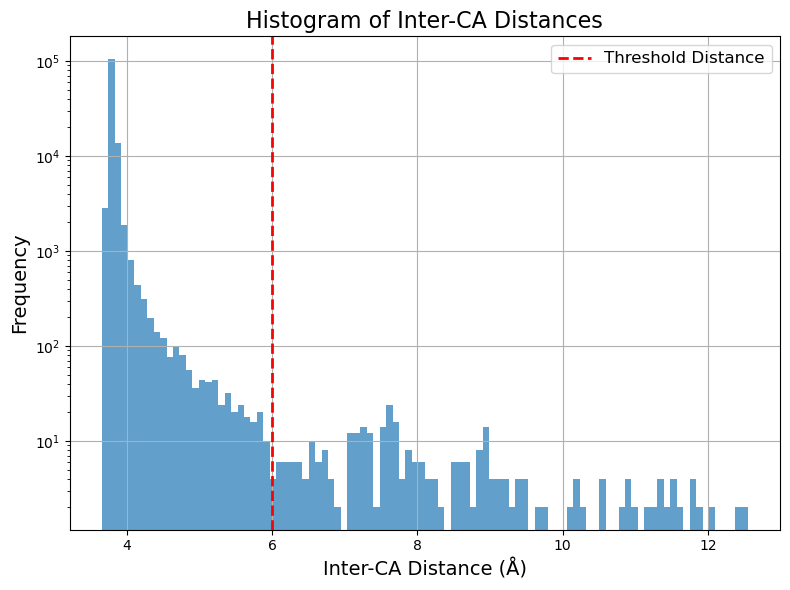

In [3]:
# Input trajectory and topology
version = "GOdMD_v1"
GOdMD_input_path = f"{data_folder}/lat1/input/GOdMD_v1"
traj_data = os.path.join(GOdMD_input_path, 'trajs') 
top_data = os.path.join(GOdMD_input_path, 'tops')

trajs, tops = check_data(traj_data, top_data)

# Load the trajectory with MDAnalysis
import MDAnalysis as mda
from MDAnalysis.analysis import distances

u = mda.Universe(tops[0], trajs[0])
ca_selection = u.select_atoms('name CA')
n_atoms = len(ca_selection)
n_frames = len(u.trajectory)

# Threshold distance to flag atoms (in Angstroms)
threshold_distance = 6.0
flagged_atoms = set()
flagged_residues = set()

inter_CA_distances = []

for ts in u.trajectory:
    # Compute the distance from each CA atom to its immediate neighbors
    for i in range(1, n_atoms - 1):
        dist_prev = distances.distance_array(ca_selection.positions[i].reshape(1, 3),
                                             ca_selection.positions[i - 1].reshape(1, 3))[0][0]
        dist_next = distances.distance_array(ca_selection.positions[i].reshape(1, 3),
                                             ca_selection.positions[i + 1].reshape(1, 3))[0][0]
        inter_CA_distances.append([dist_prev, dist_next])
        if dist_prev > threshold_distance or dist_next > threshold_distance:
            flagged_atoms.add(ca_selection.indices[i])
            flagged_residues.add(ca_selection.residues[i].resid)
        
print(f"Flagged atoms (indices): {sorted(flagged_atoms)}")
print(f"Number of flagged atoms: {len(flagged_atoms)}")
print(f"Flagged residues (resids): {sorted(flagged_residues)}")
print(f"Number of flagged residues: {len(flagged_residues)}")

# Plot histogram of inter-CA distances
inter_CA_distances = np.array(inter_CA_distances).flatten()
plt.figure(figsize=(8, 6))
plt.hist(inter_CA_distances, bins=100, alpha=0.7, log=True)
plt.axvline(threshold_distance, color='red', linestyle='dashed', linewidth=2, label='Threshold Distance')
plt.xlabel('Inter-CA Distance (Å)', fontsize=14)
plt.ylabel('Frequency', fontsize=14)
plt.title('Histogram of Inter-CA Distances', fontsize=16)
plt.legend(fontsize=12)
plt.grid(True)
plt.tight_layout()
plt.show()

## Tests before production

Here we try different configurations, features and arquitectures to find good candidates for CV models.

The transition goes from 6IRS to 7DSQ.

When training on the original 140 frames trajectory with Deep TICA the optimal number of frames for the lag time seems to be 12 (with 6 also yielding acceptable results).

In [4]:
lag_time_array = [6, 11, 12, 13]
for lag_time in lag_time_array:

    config_folder = f"{data_folder}/lat1/input"
    feature_list = ['torsions']
    cv_models = ['deep_tica']

    # Main trajectory and topology  ---> to give as main (no augmentation) or seed (augmentation)
    version = "GOdMD_v1"
    training_replica = f"_raw_{lag_time}"
    GOdMD_input_path = f"{data_folder}/lat1/input/GOdMD_v1"
    traj_data = os.path.join(GOdMD_input_path, 'trajs','GOdMD_6IRS_7DSQ_bck.dcd') 
    top_data = os.path.join(GOdMD_input_path, 'tops','GOdMD_6IRS_7DSQ_bck.pdb')

    # (Optional) Endpoint equilibrations ---> supplementary data to project onto the CV
    # Restrained equilibrations at the endpoints of the reaction coordinate
    MD_input_path = f"{data_folder}/lat1/input/MD_equil_bck"
    sup_traj_data = os.path.join(MD_input_path, 'trajs')
    sup_top_data = os.path.join(MD_input_path, 'tops')

    # (Optional) Validation trajectories ---> validation data
    # (interpolated trajs with noise without the original frames)
    val_path = f"{data_folder}/lat1/input/GOdMD_v1_200_noise_std0.1"
    val_traj_data = f"{val_path}/trajs"
    val_top_data = f"{val_path}/tops"

    for features in feature_list:
        config_path = f"{config_folder}/{features}_config.yml"
        with open(config_path) as config_file:
            configuration = yaml.load(config_file, Loader = yaml.FullLoader)
        
        configuration['train_colvars']['common']['lag_time'] = lag_time
        
        # Output folder for the full workflow
        output_folder = f"{data_folder}/lat1/output/{version}/tests/{features}{training_replica}"

        # Clean output folder
        if os.path.exists(output_folder):
            shutil.rmtree(output_folder)

        # Run workflow
        deep_cartograph(
            configuration = configuration,
            trajectory_data = traj_data,
            topology_data = top_data,
            supplementary_traj_data = sup_traj_data,
            supplementary_top_data = sup_top_data,
            waypoints_data = sup_top_data,
            cvs = cv_models,
            dimension = 1,
            restart = True,
            output_folder = output_folder)

    from deep_cartograph.modules.common import read_list

    system_name = "GOdMD_6IRS_7DSQ_bck"

    evaluation_folder = f"{data_folder}/lat1/input/GOdMD_v1_2000_noise_std0.2" #  GOdMD_v1_1000" 

    for features in feature_list:
        print("################################################################################################")
        print(f"Features: {features.upper()}")
        output_folder = f"{data_folder}/lat1/output/{version}/tests/{features}{training_replica}"
        path_full_set_features = os.path.join(output_folder, 'filter_features', 'all_features.txt')
        path_filtered_set_features = os.path.join(output_folder, 'filter_features', 'filtered_features.txt')
        full_set_features = read_list(path_full_set_features)
        filtered_set_features = read_list(path_filtered_set_features)
        print(f"Number of features in the full set: {len(full_set_features)}")
        print(f"Number of features in the filtered set: {len(filtered_set_features)}")
        for model in cv_models:
            print(f"Results for features: {features.upper()}")
            print(f"Results for model: {model.upper()}")
            print(f"Results for lag time: {lag_time} frames")
            show_results(output_folder, 
                        model_name = model, 
                        system = system_name,
                        evaluation_traj_data = os.path.join(evaluation_folder, 'trajs'),
                        evaluation_top_data = os.path.join(evaluation_folder, 'tops'))
        print("################################################################################################")

INFO:deep_cartograph:================
INFO:deep_cartograph:Analyze geometry
INFO:deep_cartograph:================
INFO:deep_cartograph:Elapsed time (Analyze geometry): 00 h 00 min 00 s
INFO:deep_cartograph:=======================
INFO:deep_cartograph:Trajectory Augmentation
INFO:deep_cartograph:=======================
INFO:deep_cartograph:Elapsed time (Trajectory Augmentation): 00 h 00 min 00 s
INFO:deep_cartograph:================
INFO:deep_cartograph:Compute features
INFO:deep_cartograph:================
/home/pnavarro/miniforge3/envs/deep_cartograph/lib/python3.10/site-packages/MDAnalysis/topology/PDBParser.py:350: UserWarning: Element information is missing, elements attribute will not be populated. If needed these can be guessed using universe.guess_TopologyAttrs(context='default', to_guess=['elements']).
  warnings.warn("Element information is missing, elements attribute "
INFO:MDAnalysis.core.universe:attribute types has been guessed successfully.
INFO:MDAnalysis.core.universe:a

Plotting only the first 20 features out of 47.
Plotting only the first 20 features out of 47.


INFO:deep_cartograph.tools.train_colvars.train_colvars_workflow:Processing trajectory: GOdMD_6IRS_7DSQ_bck
INFO:deep_cartograph.tools.train_colvars.train_colvars_workflow:Corresponding colvars file: /home/pnavarro/repos/NostrumBD/deep_cartograph/deep_cartograph/data/lat1/output/GOdMD_v1/tests/torsions_raw_6/compute_features/GOdMD_6IRS_7DSQ_bck/colvars.dat
INFO:deep_cartograph.tools.train_colvars.train_colvars_workflow:Corresponding topology file: /home/pnavarro/repos/NostrumBD/deep_cartograph/deep_cartograph/data/lat1/input/GOdMD_v1/tops/GOdMD_6IRS_7DSQ_bck.pdb
/home/pnavarro/miniforge3/envs/deep_cartograph/lib/python3.10/site-packages/MDAnalysis/topology/PDBParser.py:350: UserWarning: Element information is missing, elements attribute will not be populated. If needed these can be guessed using universe.guess_TopologyAttrs(context='default', to_guess=['elements']).
  warnings.warn("Element information is missing, elements attribute "
INFO:MDAnalysis.core.universe:attribute types has be

################################################################################################
Features: TORSIONS
Number of features in the full set: 908
Number of features in the filtered set: 47
Results for features: TORSIONS
Results for model: DEEP_TICA
Results for lag time: 6 frames
Output folder: /home/pnavarro/repos/NostrumBD/deep_cartograph/deep_cartograph/data/lat1/output/GOdMD_v1/tests/torsions_raw_6
Final model score: -1.1967E+0
Eigenvalue 1: 1.0940E+0


INFO:deep_cartograph.modules.plumed.cli:Restored working directory to: /home/pnavarro/repos/NostrumBD/deep_cartograph/examples/notebooks/7.LAT1_GOdMD
INFO:deep_cartograph:Computing features for GOdMD_v1_2000_noise_std0.2_2 with topology GOdMD_v1_2000_noise_std0.2_2...
/home/pnavarro/miniforge3/envs/deep_cartograph/lib/python3.10/site-packages/MDAnalysis/topology/PDBParser.py:350: UserWarning: Element information is missing, elements attribute will not be populated. If needed these can be guessed using universe.guess_TopologyAttrs(context='default', to_guess=['elements']).
  warnings.warn("Element information is missing, elements attribute "
/home/pnavarro/miniforge3/envs/deep_cartograph/lib/python3.10/site-packages/MDAnalysis/coordinates/PDB.py:453: UserWarning: 1 A^3 CRYST1 record, this is usually a placeholder. Unit cell dimensions will be set to None.
  warnings.warn("1 A^3 CRYST1 record,"
INFO:MDAnalysis.core.universe:attribute types has been guessed successfully.
INFO:MDAnalysis.c

...

<Figure size 500x400 with 0 Axes>

<Figure size 500x400 with 0 Axes>

<Figure size 500x400 with 0 Axes>

<Figure size 500x400 with 0 Axes>

<Figure size 500x400 with 0 Axes>

In [ ]:
lag_time_array = [6, 12]
for lag_time in lag_time_array:

    config_folder = f"{data_folder}/lat1/input"
    feature_list = ['torsions']
    cv_models = ['deep_tica']

    # Main trajectory and topology  ---> to give as main (no augmentation) or seed (augmentation)
    version = "GOdMD_v1"
    training_replica = f"_raw_{lag_time}"
    GOdMD_input_path = f"{data_folder}/lat1/input/GOdMD_v1"
    traj_data = os.path.join(GOdMD_input_path, 'trajs','GOdMD_6IRS_7DSQ_chimeric_balanced.dcd') 
    top_data = os.path.join(GOdMD_input_path, 'tops','GOdMD_6IRS_7DSQ_chimeric_balanced.pdb')

    # (Optional) Endpoint equilibrations ---> supplementary data to project onto the CV
    # Restrained equilibrations at the endpoints of the reaction coordinate
    MD_input_path = f"{data_folder}/lat1/input/MD_equil"
    sup_traj_data = os.path.join(MD_input_path, 'trajs')
    sup_top_data = os.path.join(MD_input_path, 'tops')

    # (Optional) Validation trajectories ---> validation data
    # (interpolated trajs with noise without the original frames)
    val_path = f"{data_folder}/lat1/input/GOdMD_v1_200_noise_std0.1"
    val_traj_data = f"{val_path}/trajs"
    val_top_data = f"{val_path}/tops"

    for features in feature_list:
        config_path = f"{config_folder}/{features}_config.yml"
        with open(config_path) as config_file:
            configuration = yaml.load(config_file, Loader = yaml.FullLoader)
        
        configuration['train_colvars']['common']['lag_time'] = lag_time
        
        # Output folder for the full workflow
        output_folder = f"{data_folder}/lat1/output/{version}/tests/{features}{training_replica}"

        # Clean output folder
        if os.path.exists(output_folder):
            shutil.rmtree(output_folder)

        # Run workflow
        deep_cartograph(
            configuration = configuration,
            trajectory_data = traj_data,
            topology_data = top_data,
            supplementary_traj_data = sup_traj_data,
            supplementary_top_data = sup_top_data,
            waypoints_data = sup_top_data,
            cvs = cv_models,
            dimension = 1,
            restart = True,
            output_folder = output_folder)

    from deep_cartograph.modules.common import read_list

    system_name = "GOdMD_6IRS_7DSQ_chimeric_balanced"

    evaluation_folder = f"{data_folder}/lat1/input/GOdMD_v1_2000_noise_std0.2" #  GOdMD_v1_1000" 

    for features in feature_list:
        print("################################################################################################")
        print(f"Features: {features.upper()}")
        output_folder = f"{data_folder}/lat1/output/{version}/tests/{features}{training_replica}"
        path_full_set_features = os.path.join(output_folder, 'filter_features', 'all_features.txt')
        path_filtered_set_features = os.path.join(output_folder, 'filter_features', 'filtered_features.txt')
        full_set_features = read_list(path_full_set_features)
        filtered_set_features = read_list(path_filtered_set_features)
        print(f"Number of features in the full set: {len(full_set_features)}")
        print(f"Number of features in the filtered set: {len(filtered_set_features)}")
        for model in cv_models:
            print(f"Results for features: {features.upper()}")
            print(f"Results for model: {model.upper()}")
            print(f"Results for lag time: {lag_time} frames")
            show_results(output_folder, 
                        model_name = model, 
                        system = system_name,
                        evaluation_traj_data = os.path.join(evaluation_folder, 'trajs'),
                        evaluation_top_data = os.path.join(evaluation_folder, 'tops'))
        print("################################################################################################")

In [7]:
lag_time_array = [6, 11, 12, 13, 24, 48]
lag_time_array = np.array(lag_time_array)*10 
for lag_time in lag_time_array:

    config_folder = f"{data_folder}/lat1/input"
    feature_list = ['torsions']
    cv_models = ['deep_tica']

    # Main trajectory and topology  ---> to give as main (no augmentation) or seed (augmentation)
    version = "GOdMD_v1"
    training_replica = f"_augm_{lag_time}"
    GOdMD_input_path = f"{data_folder}/lat1/input/GOdMD_v1"
    traj_data = os.path.join(GOdMD_input_path, 'trajs') 
    top_data = os.path.join(GOdMD_input_path, 'tops')

    # (Optional) Endpoint equilibrations ---> supplementary data to project onto the CV
    # Restrained equilibrations at the endpoints of the reaction coordinate
    MD_input_path = f"{data_folder}/lat1/input/MD_equil"
    sup_traj_data = os.path.join(MD_input_path, 'trajs')
    sup_top_data = os.path.join(MD_input_path, 'tops')

    # (Optional) Validation trajectories ---> validation data
    # (interpolated trajs with noise without the original frames)
    val_path = f"{data_folder}/lat1/input/GOdMD_v1_200_noise_std0.1"
    val_traj_data = f"{val_path}/trajs"
    val_top_data = f"{val_path}/tops"

    for features in feature_list:
        config_path = f"{config_folder}/{features}_config.yml"
        with open(config_path) as config_file:
            configuration = yaml.load(config_file, Loader = yaml.FullLoader)
        
        configuration['traj_augmentation']['num_frames'] = 1400 
        configuration['traj_augmentation']['keep_original_frames'] = False
        configuration['train_colvars']['common']['lag_time'] = lag_time
        
        # Output folder for the full workflow
        output_folder = f"{data_folder}/lat1/output/{version}/tests/{features}{training_replica}"

        # Clean output folder
        if os.path.exists(output_folder):
            shutil.rmtree(output_folder)

        # Run workflow
        deep_cartograph(
            configuration = configuration,
            seed_trajectory_data = traj_data,
            seed_topology_data = top_data,
            supplementary_traj_data = sup_traj_data,
            supplementary_top_data = sup_top_data,
            waypoints_data = sup_top_data,
            cvs = cv_models,
            dimension = 1,
            restart = True,
            output_folder = output_folder)

    from deep_cartograph.modules.common import read_list

    system_name = "GOdMD_6IRS_7DSQ"

    evaluation_folder = f"{data_folder}/lat1/input/GOdMD_v1_2000_noise_std0.2" #  GOdMD_v1_1000" 

    for features in feature_list:
        print("################################################################################################")
        print(f"Features: {features.upper()}")
        output_folder = f"{data_folder}/lat1/output/{version}/tests/{features}{training_replica}"
        path_full_set_features = os.path.join(output_folder, 'filter_features', 'all_features.txt')
        path_filtered_set_features = os.path.join(output_folder, 'filter_features', 'filtered_features.txt')
        full_set_features = read_list(path_full_set_features)
        filtered_set_features = read_list(path_filtered_set_features)
        print(f"Number of features in the full set: {len(full_set_features)}")
        print(f"Number of features in the filtered set: {len(filtered_set_features)}")
        for model in cv_models:
            print(f"Results for features: {features.upper()}")
            print(f"Results for model: {model.upper()}")
            print(f"Results for lag time: {lag_time} frames")
            show_results(output_folder, 
                        model_name = model, 
                        system = system_name,
                        evaluation_traj_data = os.path.join(evaluation_folder, 'trajs'),
                        evaluation_top_data = os.path.join(evaluation_folder, 'tops'))
        print("################################################################################################")

INFO:deep_cartograph:================
INFO:deep_cartograph:Compute features
INFO:deep_cartograph:================
INFO:deep_cartograph:Colvars files already exist in /home/pnavarro/repos/NostrumBD/deep_cartograph/deep_cartograph/data/lat1/output/GOdMD_v1/tests/torsions_augm_60/compute_features_eval. Skipping feature computation.


INFO:deep_cartograph:================================================================
INFO:deep_cartograph:Projection of trajectories onto pre-trained collective variables.
INFO:deep_cartograph:================================================================
INFO:deep_cartograph.tools.traj_projection.traj_projection_workflow:Starting traj_projection workflow...
INFO:deep_cartograph.modules.common.common:Starting extraction of '/home/pnavarro/repos/NostrumBD/deep_cartograph/deep_cartograph/data/lat1/output/GOdMD_v1/tests/torsions_augm_60/train_colvars/deep_tica/model.zip' to '/home/pnavarro/repos/NostrumBD/deep_cartograph/deep_cartograph/data/lat1/output/GOdMD_v1/tests/torsions_augm_60/traj_projection_eval'...
INFO:deep_cartograph.modules.common.common:Successfully extracted '/home/pnavarro/repos/NostrumBD/deep_cartograph/deep_cartograph/data/lat1/output/GOdMD_v1/tests/torsions_augm_60/train_colvars/deep_tica/model.zip' to '/home/pnavarro/repos/NostrumBD/deep_cartograph/deep_cartograph/

################################################################################################
Features: TORSIONS
Number of features in the full set: 908
Number of features in the filtered set: 118
Results for features: TORSIONS
Results for model: DEEP_TICA
Results for lag time: 60 frames
Output folder: /home/pnavarro/repos/NostrumBD/deep_cartograph/deep_cartograph/data/lat1/output/GOdMD_v1/tests/torsions_augm_60
Final model score: -9.3908E-1
Eigenvalue 1: 9.6688E-1


INFO:deep_cartograph.modules.cv_learning.cv_calculator:Creating DeepTICA Calculator ...
INFO:deep_cartograph.tools.traj_projection.traj_projection_workflow:Projected trajectory files for CV deep_tica already exist. Skipping projection...
INFO:deep_cartograph:Elapsed time (Project trajectories): 00 h 00 min 01 s
INFO:root:Processing 4 evaluation datasets for error estimation.
/tmp/ipykernel_15629/579387491.py:109: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', n_components)


INFO:deep_cartograph:================
INFO:deep_cartograph:Compute features
INFO:deep_cartograph:================
INFO:deep_cartograph:Colvars files already exist in /home/pnavarro/repos/NostrumBD/deep_cartograph/deep_cartograph/data/lat1/output/GOdMD_v1/tests/torsions_augm_110/compute_features_eval. Skipping feature computation.
INFO:deep_cartograph:================================================================
INFO:deep_cartograph:Projection of trajectories onto pre-trained collective variables.
INFO:deep_cartograph:================================================================
INFO:deep_cartograph.tools.traj_projection.traj_projection_workflow:Starting traj_projection workflow...
INFO:deep_cartograph.modules.common.common:Starting extraction of '/home/pnavarro/repos/NostrumBD/deep_cartograph/deep_cartograph/data/lat1/output/GOdMD_v1/tests/torsions_augm_110/train_colvars/deep_tica/model.zip' to '/home/pnavarro/repos/NostrumBD/deep_cartograph/deep_cartograph/data/lat1/output/GOdMD

...

/tmp/ipykernel_15629/579387491.py:109: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', n_components)


INFO:deep_cartograph:================
INFO:deep_cartograph:Compute features
INFO:deep_cartograph:================
INFO:deep_cartograph:Colvars files already exist in /home/pnavarro/repos/NostrumBD/deep_cartograph/deep_cartograph/data/lat1/output/GOdMD_v1/tests/torsions_augm_480/compute_features_eval. Skipping feature computation.
INFO:deep_cartograph:================================================================
INFO:deep_cartograph:Projection of trajectories onto pre-trained collective variables.
INFO:deep_cartograph:================================================================
INFO:deep_cartograph.tools.traj_projection.traj_projection_workflow:Starting traj_projection workflow...
INFO:deep_cartograph.modules.common.common:Starting extraction of '/home/pnavarro/repos/NostrumBD/deep_cartograph/deep_cartograph/data/lat1/output/GOdMD_v1/tests/torsions_augm_480/train_colvars/deep_tica/model.zip' to '/home/pnavarro/repos/NostrumBD/deep_cartograph/deep_cartograph/data/lat1/output/GOdMD

################################################################################################
################################################################################################
Features: TORSIONS
Number of features in the full set: 908
Number of features in the filtered set: 118
Results for features: TORSIONS
Results for model: DEEP_TICA
Results for lag time: 480 frames
Output folder: /home/pnavarro/repos/NostrumBD/deep_cartograph/deep_cartograph/data/lat1/output/GOdMD_v1/tests/torsions_augm_480
Final model score: -8.1601E+7
Eigenvalue 1: -8.9828E+3


/tmp/ipykernel_15629/579387491.py:109: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', n_components)


################################################################################################
